In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

import numpy as np

from statsmodels.stats.multitest import multipletests

from figure_params import *


/home/njharlen/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Figure 4A - Monocyte U-MAP

In [2]:
#cell_type = 'Monocyte'

adata_i = sc.read('../data/FL_scRNA_nonBcell_annotated.h5ad')


adata_m = adata_i[adata_i.obs['cell_type_coarse']=='Monocyte'].copy()

/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Text(0.5, 1.0, '')

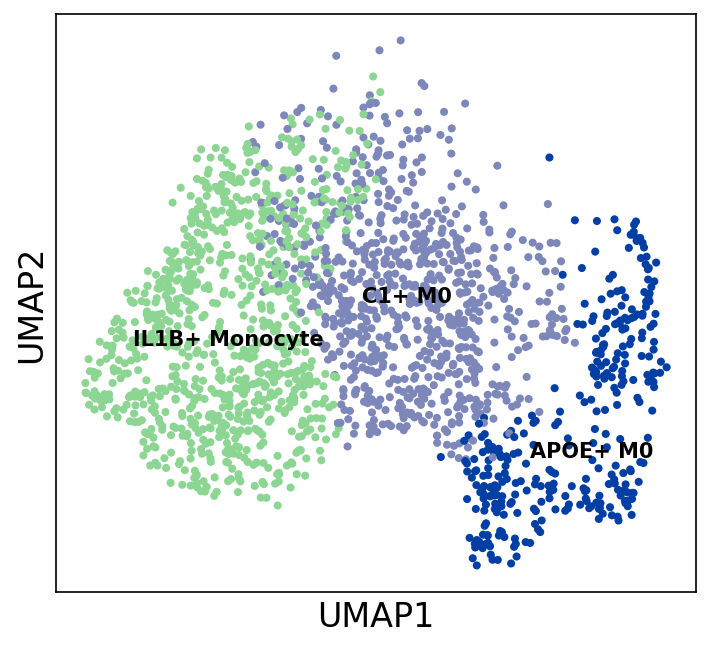

In [3]:
f,ax = plt.subplots(1,figsize=(5.5,5))
sc.pl.umap(adata_m,color='cell_type_fine',legend_loc = 'on data',show=False,ax=ax)
ax.set_title('')

## Figure 4B - Monocyte subpopulation marker heatmap

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='cell_type_fine'>,
 'dendrogram_ax': <Axes: >,
 'gene_groups_ax': <Axes: >}

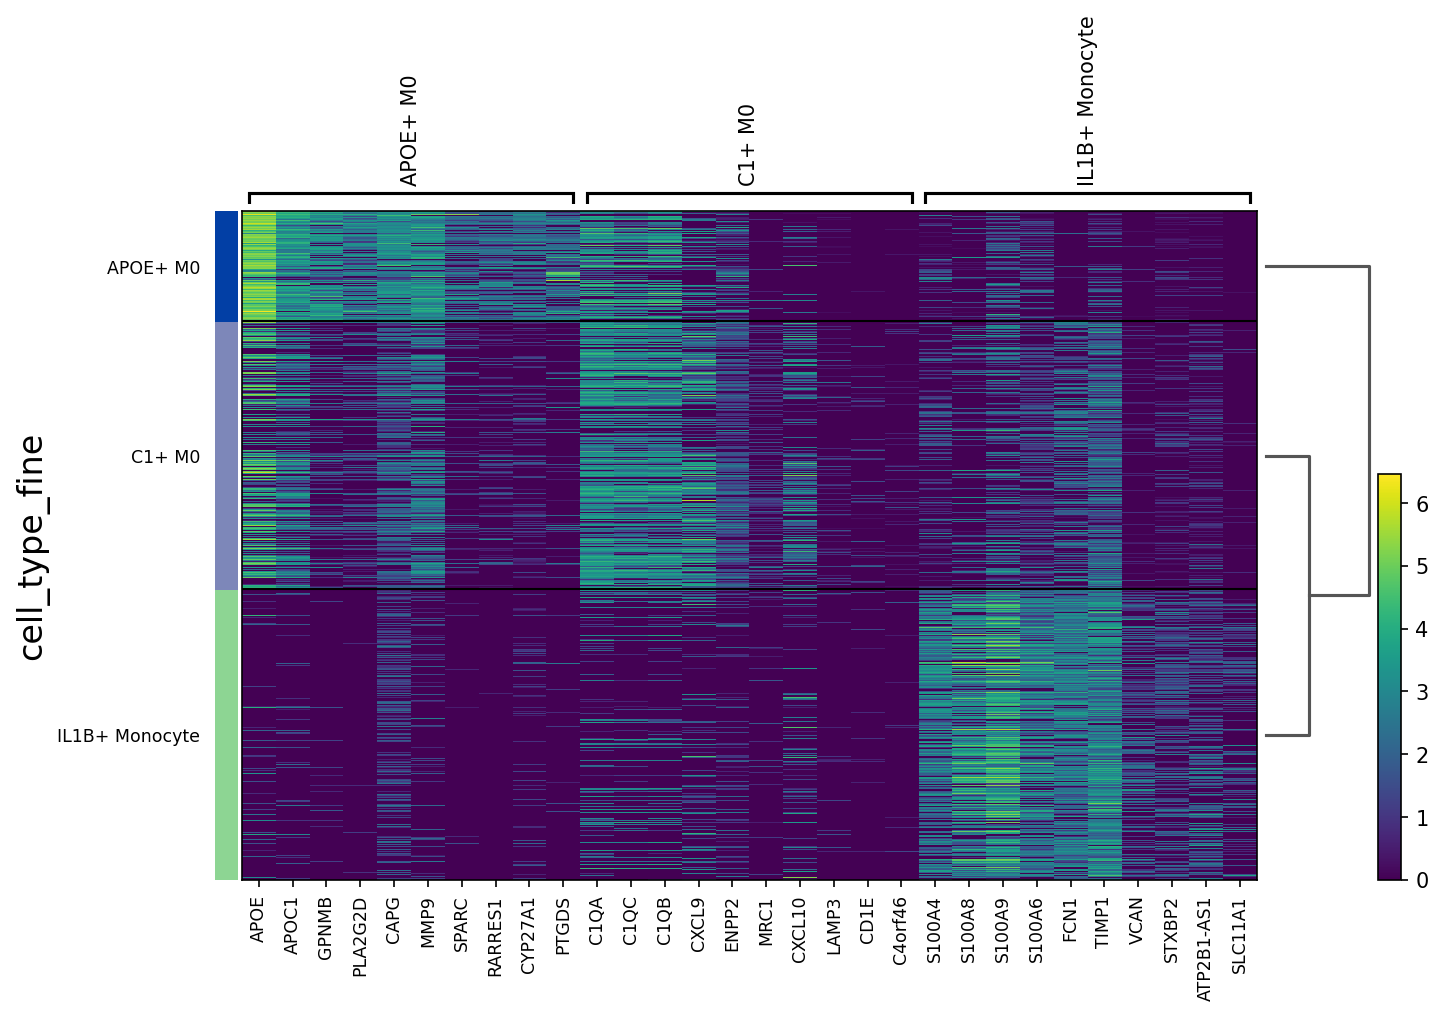

In [4]:
sc.tl.rank_genes_groups(adata_m,'cell_type_fine')
sc.tl.dendrogram(adata_m,'cell_type_fine')
sc.pl.rank_genes_groups_heatmap(adata_m,n_genes=10,show_gene_labels=True,min_logfoldchange=2,show=False)

## Figure 4C - GeoMX validation

In [5]:
adata_geo = sc.read('../data/FL_geomx.h5ad')
sc.pp.log1p(adata_geo)

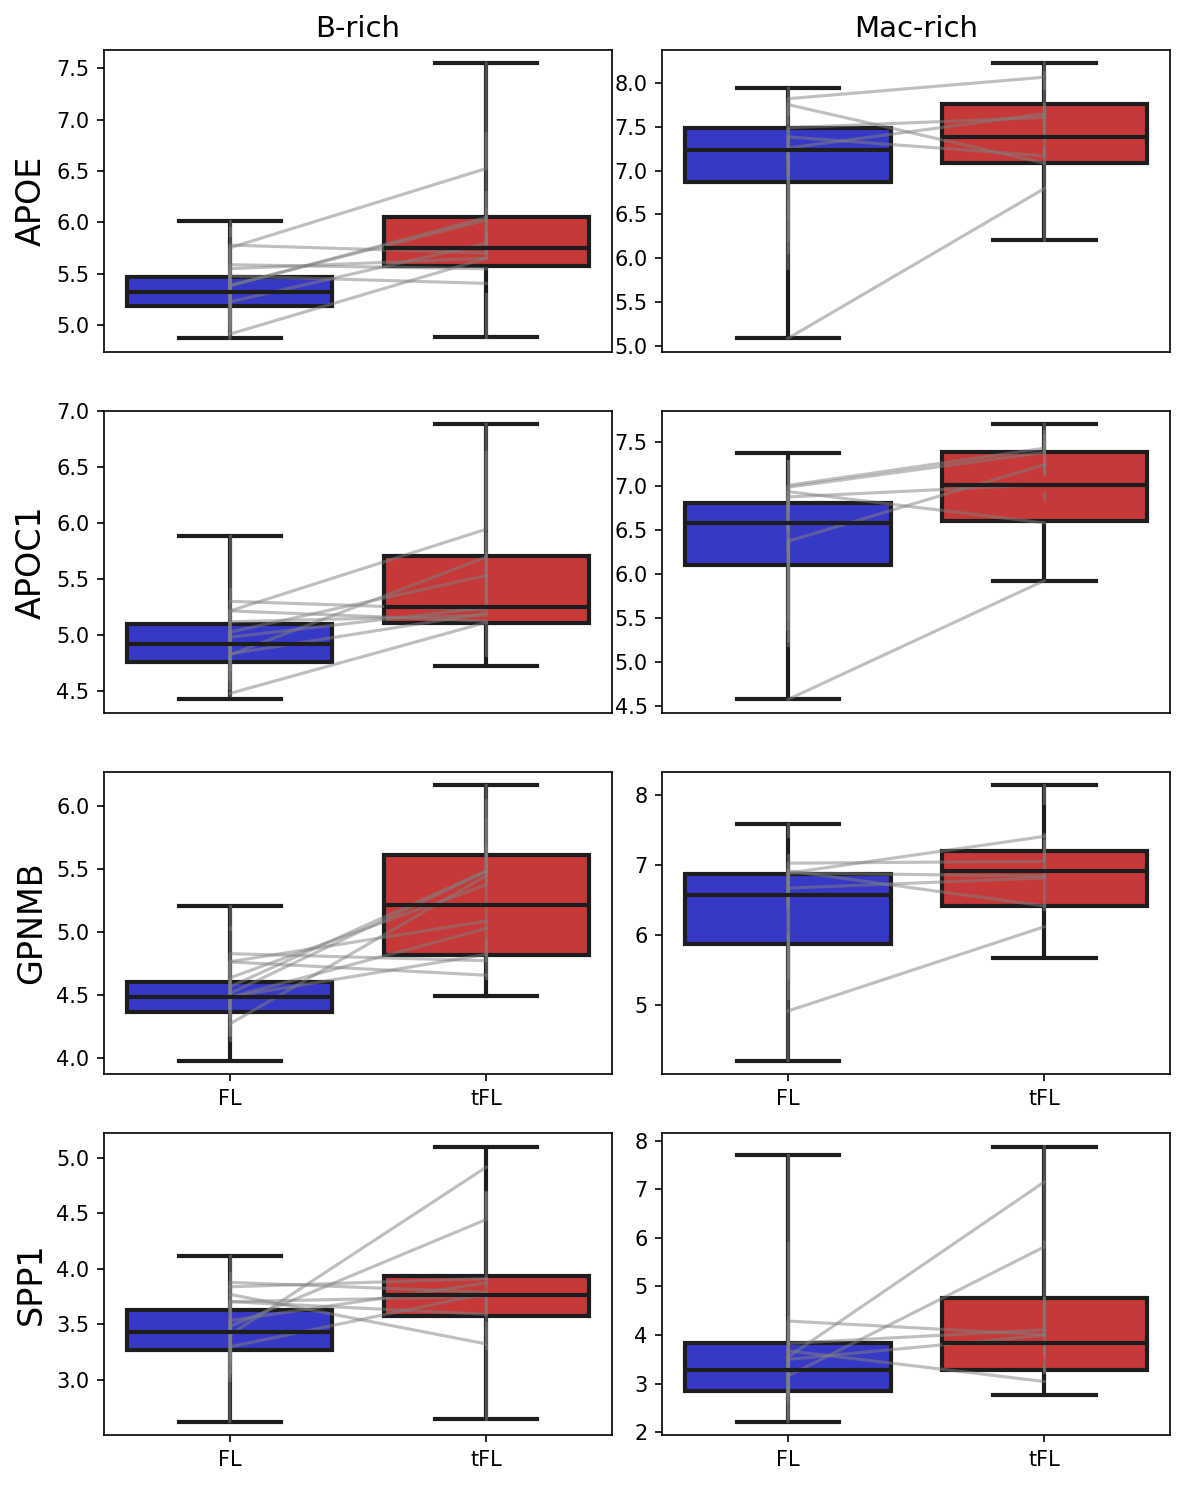

In [6]:
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel

genes = ['APOE','APOC1','GPNMB','SPP1']

seg_label = {'Bcell':'B-rich','Mac' : 'Mac-rich'}

f,ax = plt.subplots(4,2,figsize=(8,10))

i=0
for g in genes:
    j=0
    for seg in ['Bcell','Mac']:
        idx = adata_geo.obs['SegmentLabel']==seg
        df = adata_geo.obs[idx].join(adata_geo[idx,g].to_df())

        sns.boxplot(x="disease",y=g,data=df,hue="disease",palette=disease_colors,ax=ax[i,j],
                    legend=False,whis=100,linewidth=2)
        sns.lineplot(x="disease",y=g,units="patient",estimator=None,
             data=df,legend=False,color='grey',markers=True,ax=ax[i,j],alpha=.5)
        
        if j > 0:
            ax[i,j].set_ylabel('')
            
        if i==0:
            ax[i,j].set_title(seg_label[seg],fontsize=14)
            
        if i<2:
            ax[i,j].set_xticks([])
            
        ax[i,j].set_xlabel('')

        j+=1

    i+=1
plt.tight_layout()

## Figure 4D - Bulk validation

In [7]:
X = pd.read_csv('../data/bulk_RNA_gene_expression_matrix.csv.gz',index_col='gene_name')
S = pd.read_csv('../data/bulk_metadata.txt',index_col='sample',sep='\t')

S = S[S['disease'].isin(['FL','tFL'])]
X = X.loc[:,S.index].T

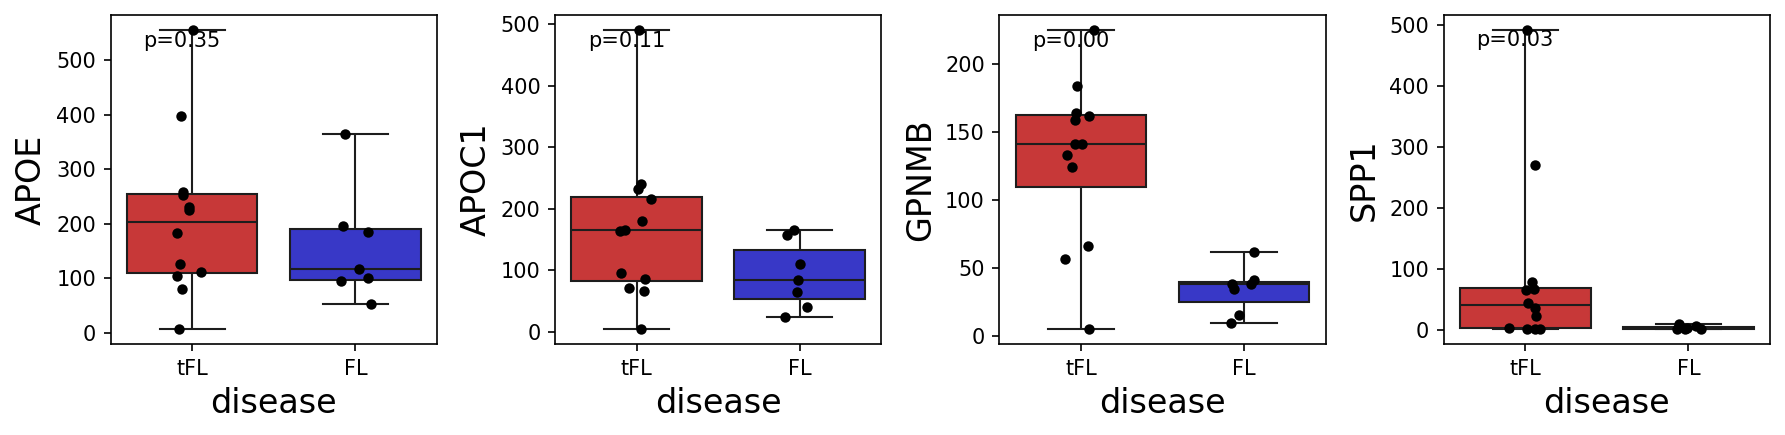

In [8]:
from scipy.stats import ranksums
gshow = ['APOE','APOC1','GPNMB','SPP1']

f,ax = plt.subplots(1,4,figsize=(12,3))
ax=ax.reshape(-1)

i=0
for g in gshow:
    sns.stripplot(x=S['disease'],y=g,data=X,ax=ax[i],color='k')
    sns.boxplot(x=S['disease'],y=g,data=X,ax=ax[i],whis=1000,hue=S['disease'],palette=disease_colors)
    
    r,p = ranksums(X.loc[S['disease']=='FL',g],
            X.loc[S['disease']=='tFL',g])

    ax[i].text(-.3,.9 * ax[i].get_ylim()[1],f'p={p:.2f}')
    
    i+=1
plt.tight_layout()

## Figure 4E - SPP1 interactions scRNA

In [9]:
from ggsc.pseudobulk import calc_pseudobulk_tpm

In [10]:
X_fine = calc_pseudobulk_tpm(adata_i,'cell_type_fine')

Using total_counts for total counts column...


/home/njharlen/git/ggsctools/ggsc/pseudobulk.py:46: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_ref = ad.AnnData(X,var=adata_ref.var,obs=adata.obs)


In [11]:
ct_order = adata_i.obs[['cell_type_coarse','cell_type_fine']].\
            drop_duplicates().sort_values('cell_type_coarse').reset_index(drop=True)
ct_order['category'] = 'Stroma'
ct_order.loc[ct_order['cell_type_coarse'].isin(['T','NK','Monocyte']),'category'] = 'Immune'
ct_order = ct_order.sort_values(['category','cell_type_coarse'])

# Add tumor
order_tumor = pd.DataFrame(X_fine.index[~X_fine.index.isin(ct_order['cell_type_fine'])],columns=['cell_type_fine'])
order_tumor = order_tumor.sort_values('cell_type_fine',ascending=False)
ct_order = pd.concat([ct_order,order_tumor])


ct_order['cell_type_coarse'] = ct_order['cell_type_coarse'].astype(str).str.replace('nan','Tumor')
ct_order['category'] = ct_order['category'].astype(str).str.replace('nan','Tumor')

In [12]:
from util import make_lr_plot,draw_subdivisions

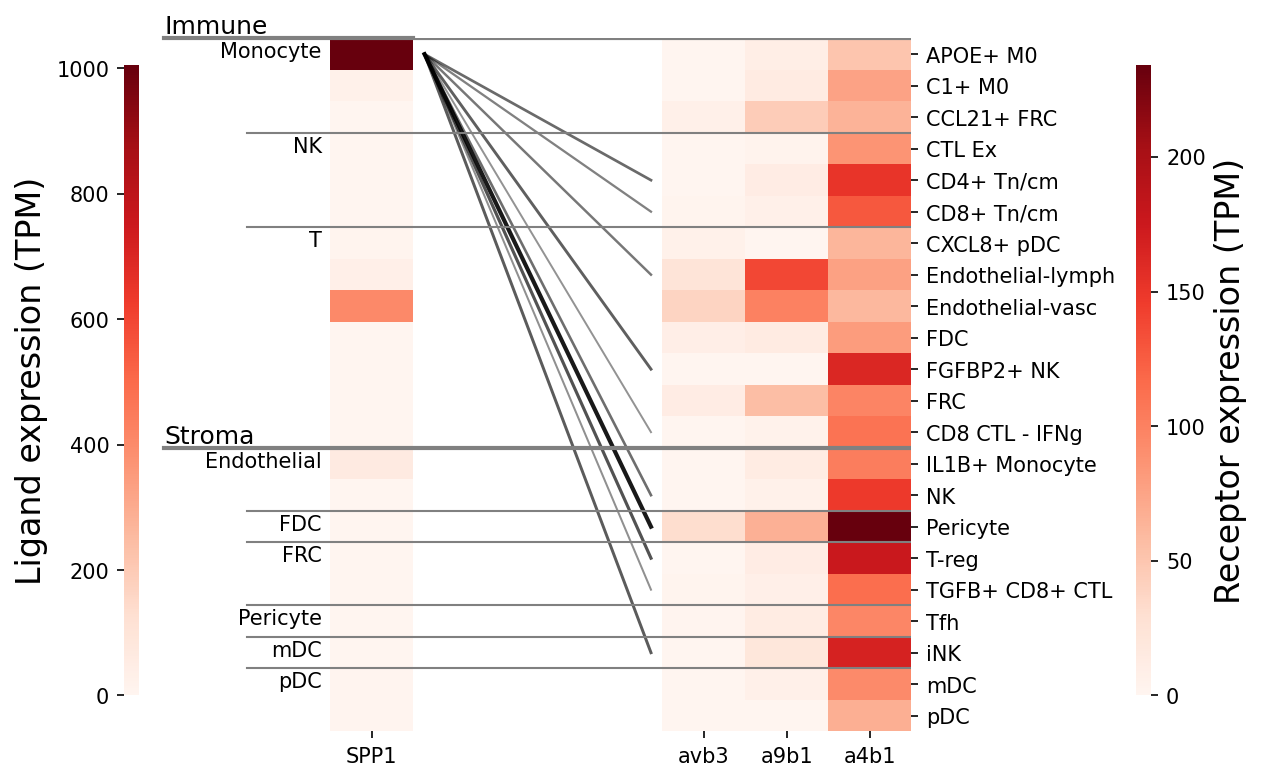

In [13]:
spp1_targets = {'avb3' : ['ITGAV','ITGB3'],
            'a9b1' : ['ITGA9','ITGB1'],
            'a4b1' : ['ITGA4','ITGB1']}

ax = make_lr_plot(X_fine,['SPP1'],spp1_targets,cbar=True)
    
draw_subdivisions(ct_order,'category','cell_type_coarse',ax=ax)


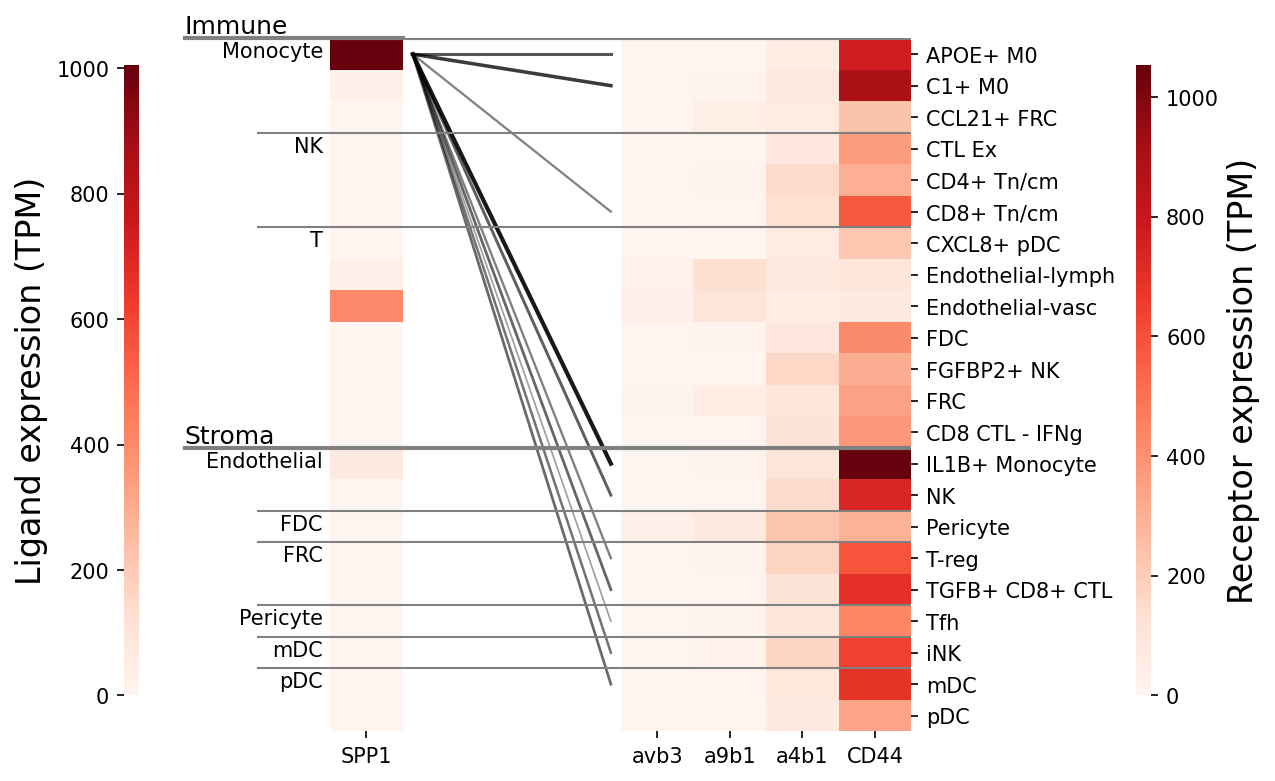

In [14]:
spp1_targets = {'avb3' : ['ITGAV','ITGB3'],
            'a9b1' : ['ITGA9','ITGB1'],
            'a4b1' : ['ITGA4','ITGB1'],
               'CD44':['CD44']}

ax=make_lr_plot(X_fine,['SPP1'],spp1_targets,cbar=True)
draw_subdivisions(ct_order,'category','cell_type_coarse',ax=ax)

## Figure 4F - SPP1 interaction scatters GeoMX

In [15]:
from util import geomx_interaction_plot

/home/njharlen/anaconda3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/njharlen/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/njharlen/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/njharlen/anaconda3/lib/python3.8/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/njharlen/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retr

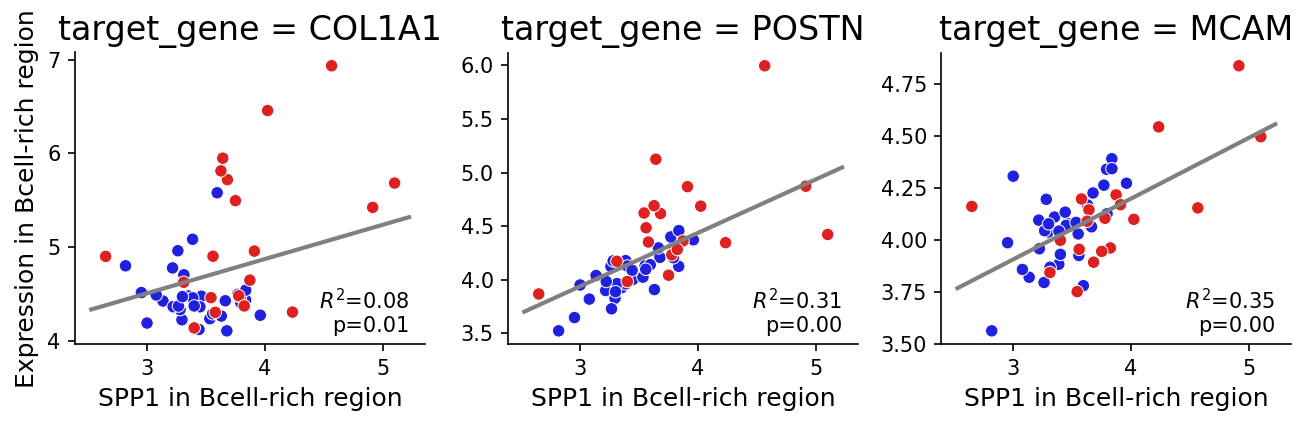

In [16]:
geomx_interaction_plot(adata_geo,
            source_gene='SPP1',
            target_genes=['COL1A1','POSTN','MCAM'],
            source_region='Bcell',
            target_region='Bcell',
                       hue="disease",
                       plot_type='mixedlm',
                       palette=disease_colors)

## Figure 4G - CXCL9 interactions

In [17]:
source_gene = 'CXCL9'
source_region='Mac'
target_genes = ['CXCR3','NKG7','GZMB','IFNG','TGFB1','PDCD1']
target_region='Tcell'

plot_genes2(adata_geo,source_gene,
            target_genes,
            source_region,
            target_region,hue="disease",plot_type='mixedlm')

NameError: name 'plot_genes2' is not defined

## Figure 4I - CXCL9 distribution

In [ ]:
df = adata_geo[adata_geo.obs['SegmentLabel']=='Tcell',genes].to_df().join(adata_geo.obs).set_index('ROILabel')
df = df.join(adata_geo[adata_geo.obs['SegmentLabel']=='Bcell','CXCL9'].to_df().join(adata_geo.obs[['ROILabel']]).\
            set_index('ROILabel'))
df = df.groupby(['sample_id','disease']).mean().reset_index().dropna(subset='CXCL9')

sns.histplot(data=df,x='CXCL9',hue='disease',stat='percent',alpha=.4,common_norm=False,element='poly')

plt.xlabel('CXCL9 expression')

In [ ]:
from scipy.stats import levene
levene(df.loc[df['disease']=='FL','CXCL9'],
      df.loc[df['disease']=='tFL','CXCL9'])